# 02 - Translation Lineage

Visualizes the translation lineage graph from `src/graph_builder.build_translation_lineage_graph`: which source texts and prior translations fed into which later translations, and how that lineage diverges by tradition (e.g. Luther's Bible vs. Douay-Rheims both drawing on the Vulgate/Hebrew/Greek tradition in different combinations).

**Status:** edges are now sourced (2026-07-19) - see 'Sourcing the Translation Lineage Graph' in `docs/historical_notes.md` for the full research log, including two corrections against the original placeholder edges (the Septuagint does not descend from the Masoretic Text; no documented Luther's Bible -> KJV dependency was found, so that edge was replaced with the real Tyndale/Great Bible/Bishops' Bible chain). Each edge below carries a `date` and `note` (citation number or a flag like 'reference, not primary source').

In [1]:
import sys
sys.path.append('../src')

from graph_builder import build_translation_lineage_graph

import matplotlib.pyplot as plt
import networkx as nx

## Build the lineage graph

In [2]:
G = build_translation_lineage_graph()

print(f'{G.number_of_nodes()} texts, {G.number_of_edges()} lineage edges')
print()
for source, target, data in G.edges(data=True):
    note = f" -- {data['note']}" if data['note'] else ''
    print(f"[{data['date']}] {source} -> {target}{note}")

14 texts, 20 lineage edges

[c. 250-132 BC] Hebrew Source Texts (Second Temple era, textually plural) -> Septuagint (LXX) -- translation; LXX's Hebrew Vorlage differed from the proto-Masoretic tradition in places, per Dead Sea Scroll evidence [7]
[dominant by 1st c. AD; vocalized/codified by the Masoretes c. 7th-10th c. AD] Hebrew Source Texts (Second Temple era, textually plural) -> Masoretic Text -- standardization, not translation
[c. 2nd c. AD] Septuagint (LXX) -> Old Latin (Vetus Latina) -- Old Testament translated from the LXX, not from Hebrew
[382-405 AD] Masoretic Text -> Vulgate -- protocanonical OT translated directly from Hebrew (hebraica veritas); Jerome used the pre-codification 4th-c. form of this tradition [12]
[1534] Masoretic Text -> Luther's Bible (1534) -- OT translated from Hebrew (Bomberg/Ben Chayyim ed., 1524-25) [10]
[1530] Masoretic Text -> Tyndale's Bible (NT 1526, Pentateuch 1530) -- Pentateuch translated from Hebrew
[1611] Masoretic Text -> King James Version

## Topological check

The lineage graph should be a DAG (no text can be its own ancestor) - this confirms the edge list is structurally sound.

In [3]:
assert nx.is_directed_acyclic_graph(G), 'Lineage graph must be acyclic'
print('OK: lineage graph is a valid DAG')
print('Topological order:', list(nx.topological_sort(G)))

OK: lineage graph is a valid DAG
Topological order: ['Hebrew Source Texts (Second Temple era, textually plural)', 'Greek New Testament (1st c. manuscripts)', "Erasmus's Greek NT (Textus Receptus)", 'Septuagint (LXX)', 'Masoretic Text', 'Old Latin (Vetus Latina)', "Tyndale's Bible (NT 1526, Pentateuch 1530)", 'Vulgate', 'Great Bible (1539)', 'Geneva Bible (1560)', 'Douay-Rheims (NT 1582, OT 1609-10)', "Luther's Bible (1534)", "Bishops' Bible (1568)", 'King James Version (1611)']


## Visualize

Node positions are a generic spring layout, not a chronological timeline - dates live in the edge data printed above, not in node placement. Treat this as showing *what fed into what*, not *when*.

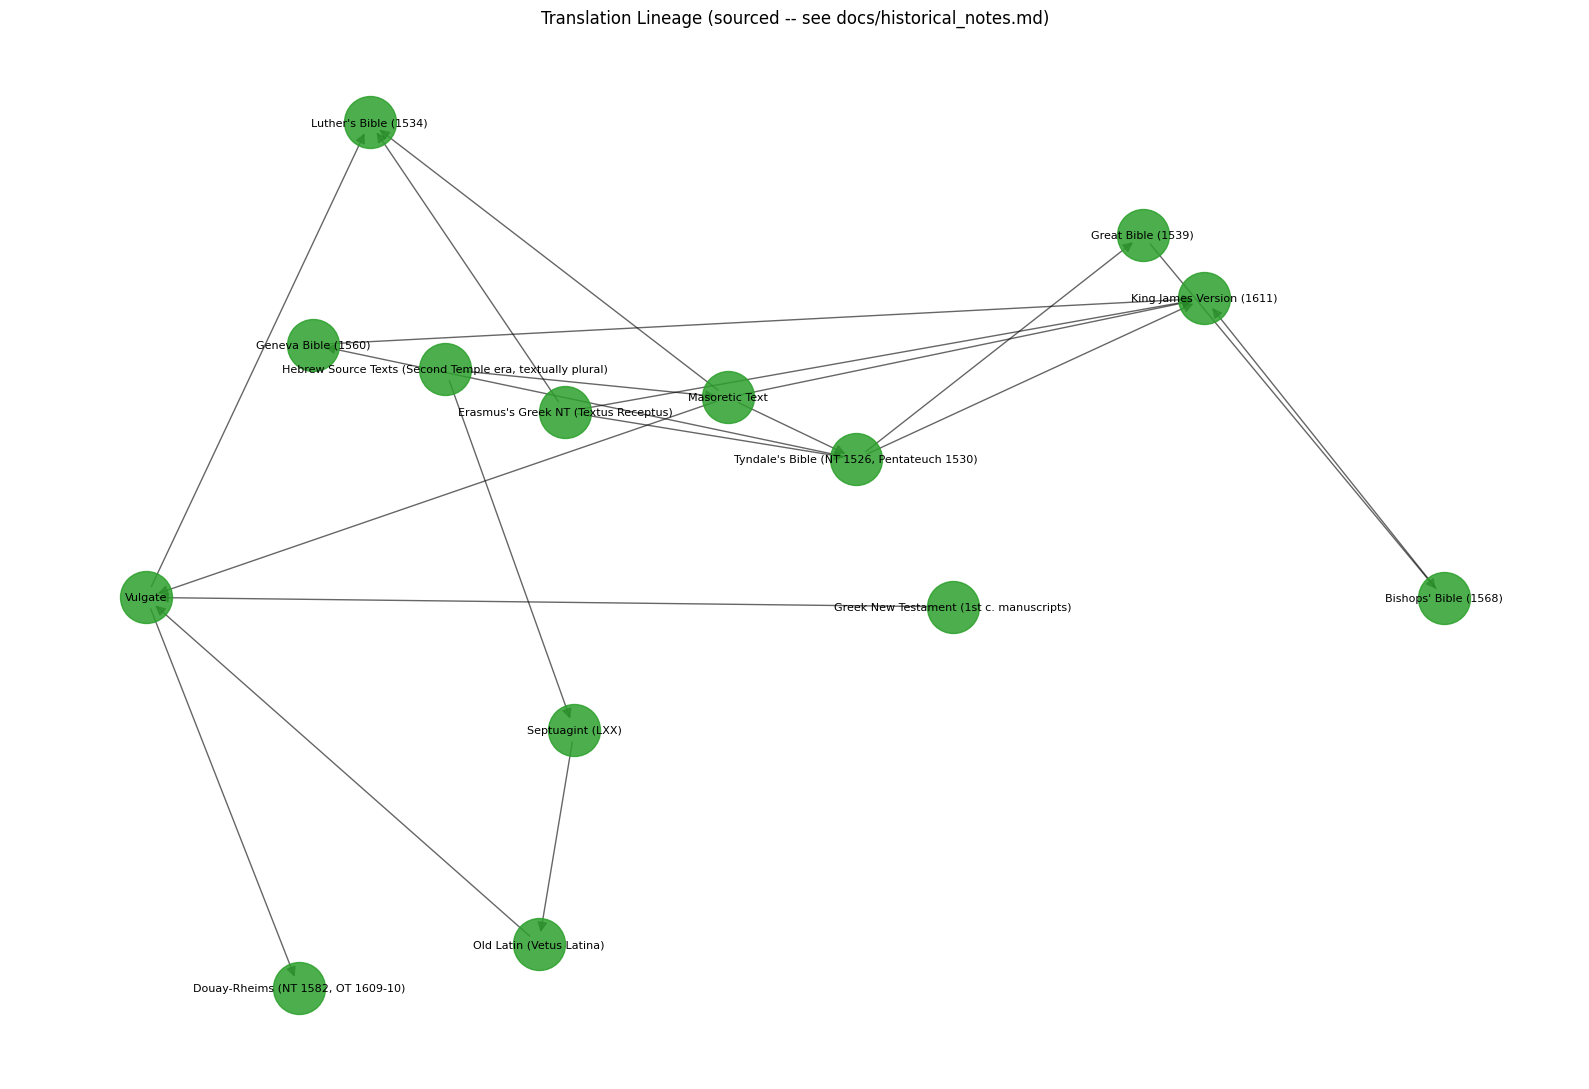

In [4]:
pos = nx.spring_layout(G, seed=7, k=1.1)

fig, ax = plt.subplots(figsize=(16, 11))

nx.draw_networkx_nodes(G, pos, node_color='tab:green', node_size=1400, alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=15, alpha=0.6, ax=ax)

ax.set_title('Translation Lineage (sourced -- see docs/historical_notes.md)')
ax.axis('off')
plt.tight_layout()
plt.savefig('../outputs/figures/translation_lineage_graph.png', dpi=150)
plt.show()

## Next steps

- Pin the ~80% Tyndale/KJV New Testament wording figure (reference [9] in historical_notes.md) to a specific peer-reviewed source if this graph goes in the thesis itself - currently cited as a widely-repeated secondary figure, not traced to one primary count.
- Add missing branches if the project scope extends to them: Peshitta, Coptic versions, Wycliffe's Bible, modern critical editions (Nestle-Aland, BHS).
- Consider a chronological layout (e.g. node x-position driven by date) instead of the generic spring layout, now that every edge carries a real date.